In [ ]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("customer_loan_dataset_1000_rows_realistic.csv")
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1,56.0,Female,West,Secondary,Salaried,732731.21,399317.59,Education,321.0,7,179,79.81,2018-01-26 12:25:06.071298,0
1,2,69.0,Male,East,Secondary,Unemployed,692733.31,10690.50,Other,424.0,8,65,50.61,2019-11-08 12:25:06.071317,0
2,3,46.0,Male,West,Primary,Salaried,672135.84,448416.31,Business,378.0,5,52,74.64,2020-04-04 12:25:06.071320,0
3,4,32.0,Male,South,Graduate,Unemployed,606826.40,488994.53,Education,NaN,5,30,39.45,2017-02-21 12:25:06.071323,0
4,5,60.0,Male,North,Primary,Salaried,757308.01,326667.73,Home,475.0,1,185,20.01,2017-12-06 12:25:06.071325,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1000 non-null   int64  
 1   age                950 non-null    float64
 2   gender             1000 non-null   str    
 3   region             1000 non-null   str    
 4   education_level    1000 non-null   str    
 5   employment_type    950 non-null    str    
 6   annual_income      950 non-null    float64
 7   loan_amount        1000 non-null   float64
 8   loan_purpose       1000 non-null   str    
 9   credit_score       950 non-null    float64
 10  repayment_history  1000 non-null   int64  
 11  transaction_count  1000 non-null   int64  
 12  spending_ratio     1000 non-null   float64
 13  join_date          1000 non-null   str    
 14  default_flag       1000 non-null   int64  
dtypes: float64(5), int64(4), str(6)
memory usage: 117.3 KB


In [ ]:
df.describe()

,customer_id,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag
count,1000.000000,950.000000,9.500000e+02,1.000000e+03,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.971579,6.441565e+05,3.188280e+05,571.263158,4.586000,96.588000,50.218170,0.094000
std,288.819436,15.008050,4.257270e+05,1.908713e+05,160.015246,2.898794,57.266305,22.851488,0.291975
min,1.000000,18.000000,-4.788754e+04,-1.404243e+05,300.000000,0.000000,1.000000,10.010000,0.000000
25%,250.750000,31.000000,4.644745e+05,2.087409e+05,429.000000,2.000000,47.000000,30.827500,0.000000
50%,500.500000,44.000000,6.055111e+05,3.060602e+05,573.000000,5.000000,94.500000,50.640000,0.000000
75%,750.250000,56.000000,7.408913e+05,4.049459e+05,711.750000,7.000000,145.000000,69.830000,0.000000
max,1000.000000,69.000000,5.750107e+06,2.216707e+06,850.000000,9.000000,199.000000,89.960000,1.000000


In [ ]:
df.isnull().sum()

customer_id           0
age                  50
gender                0
region                0
education_level       0
employment_type      50
annual_income        50
loan_amount           0
loan_purpose          0
credit_score         50
repayment_history     0
transaction_count     0
spending_ratio        0
join_date             0
default_flag          0
dtype: int64

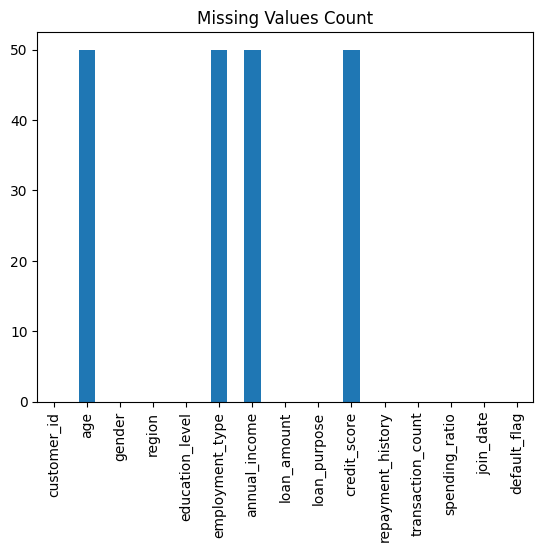

In [ ]:
missing = df.isnull().sum()

plt.figure()
missing.plot(kind='bar')
plt.xticks(rotation=90)
plt.title("Missing Values Count")
plt.show()

# Handling missing data

Simple Imputer (numerical: meaWmedian)

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

df.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1.0,56.0,Female,West,Secondary,Salaried,732731.21,399317.59,Education,321.000000,7.0,179.0,79.81,2018-01-26 12:25:06.071298,0.0
1,2.0,69.0,Male,East,Secondary,Unemployed,692733.31,10690.50,Other,424.000000,8.0,65.0,50.61,2019-11-08 12:25:06.071317,0.0
2,3.0,46.0,Male,West,Primary,Salaried,672135.84,448416.31,Business,378.000000,5.0,52.0,74.64,2020-04-04 12:25:06.071320,0.0
3,4.0,32.0,Male,South,Graduate,Unemployed,606826.40,488994.53,Education,571.263158,5.0,30.0,39.45,2017-02-21 12:25:06.071323,0.0
4,5.0,60.0,Male,North,Primary,Salaried,757308.01,326667.73,Home,475.000000,1.0,185.0,20.01,2017-12-06 12:25:06.071325,0.0


Simple Imputer (categorical: most frequent).

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.head()


C:\Users\Rwn\AppData\Local\Temp\ipykernel_15852\1681204987.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1.0,56.0,Female,West,Secondary,Salaried,732731.21,399317.59,Education,321.000000,7.0,179.0,79.81,2018-01-26 12:25:06.071298,0.0
1,2.0,69.0,Male,East,Secondary,Unemployed,692733.31,10690.50,Other,424.000000,8.0,65.0,50.61,2019-11-08 12:25:06.071317,0.0
2,3.0,46.0,Male,West,Primary,Salaried,672135.84,448416.31,Business,378.000000,5.0,52.0,74.64,2020-04-04 12:25:06.071320,0.0
3,4.0,32.0,Male,South,Graduate,Unemployed,606826.40,488994.53,Education,571.263158,5.0,30.0,39.45,2017-02-21 12:25:06.071323,0.0
4,5.0,60.0,Male,North,Primary,Salaried,757308.01,326667.73,Home,475.000000,1.0,185.0,20.01,2017-12-06 12:25:06.071325,0.0


Most Frequent Category Imputation:-

In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col + "_missing"] = df[col].isnull().astype(int)
        random_sample = df[col].dropna().sample(df[col].isnull().sum(), random_state=0)
        random_sample.index = df[df[col].isnull()].index
        df.loc[df[col].isnull(), col] = random_sample

df.isnull().sum()


customer_id          0
age                  0
gender               0
region               0
education_level      0
employment_type      0
annual_income        0
loan_amount          0
loan_purpose         0
credit_score         0
repayment_history    0
transaction_count    0
spending_ratio       0
join_date            0
default_flag         0
dtype: int64

*KNNImputer* (multivariate)

In [ ]:


knn_imputer = KNNImputer(n_neighbors=5)
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

df.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1.0,56.0,Female,West,Secondary,Salaried,732731.21,399317.59,Education,321.000000,7.0,179.0,79.81,2018-01-26 12:25:06.071298,0.0
1,2.0,69.0,Male,East,Secondary,Unemployed,692733.31,10690.50,Other,424.000000,8.0,65.0,50.61,2019-11-08 12:25:06.071317,0.0
2,3.0,46.0,Male,West,Primary,Salaried,672135.84,448416.31,Business,378.000000,5.0,52.0,74.64,2020-04-04 12:25:06.071320,0.0
3,4.0,32.0,Male,South,Graduate,Unemployed,606826.40,488994.53,Education,571.263158,5.0,30.0,39.45,2017-02-21 12:25:06.071323,0.0
4,5.0,60.0,Male,North,Primary,Salaried,757308.01,326667.73,Home,475.000000,1.0,185.0,20.01,2017-12-06 12:25:06.071325,0.0


MICE Algorithm :-

In [ ]:


mice_imputer = IterativeImputer(random_state=0)
df[num_cols] = mice_imputer.fit_transform(df[num_cols])

df.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1.0,56.0,Female,West,Secondary,Salaried,732731.21,399317.59,Education,321.000000,7.0,179.0,79.81,2018-01-26 12:25:06.071298,0.0
1,2.0,69.0,Male,East,Secondary,Unemployed,692733.31,10690.50,Other,424.000000,8.0,65.0,50.61,2019-11-08 12:25:06.071317,0.0
2,3.0,46.0,Male,West,Primary,Salaried,672135.84,448416.31,Business,378.000000,5.0,52.0,74.64,2020-04-04 12:25:06.071320,0.0
3,4.0,32.0,Male,South,Graduate,Unemployed,606826.40,488994.53,Education,571.263158,5.0,30.0,39.45,2017-02-21 12:25:06.071323,0.0
4,5.0,60.0,Male,North,Primary,Salaried,757308.01,326667.73,Home,475.000000,1.0,185.0,20.01,2017-12-06 12:25:06.071325,0.0


# drop value :-

In [ ]:
df_drop_rows = df.dropna()
df_drop_rows.shape


(1000, 15)

In [ ]:
df_drop_cols = df.dropna(axis=1)
df_drop_cols.shape


(1000, 15)

# Part D: Outlier Handling

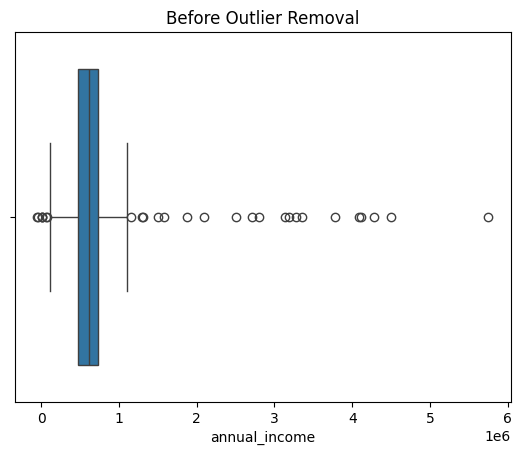

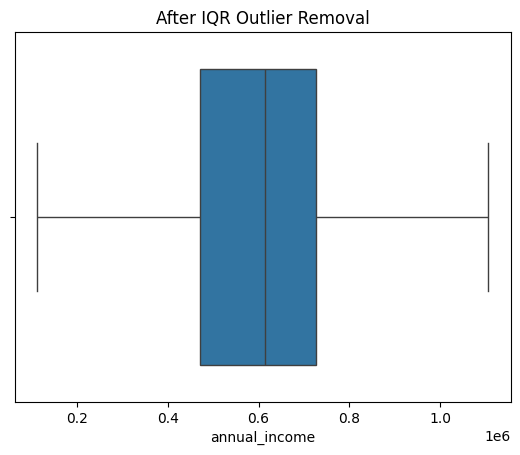

In [ ]:
plt.figure()
sns.boxplot(x=df['annual_income'])
plt.title("Before Outlier Removal")
plt.show()

plt.figure()
sns.boxplot(x=df_iqr_removed['annual_income'])
plt.title("After IQR Outlier Removal")
plt.show()

Before IQR removal, annual_income had several extreme outliers, while after applying IQR, the distribution becomes more compact and balanced with outliers effectively removed.

Z-Score Method

In [ ]:
from scipy import stats

num_cols = df.select_dtypes(include=np.number).columns

z_scores = np.abs(stats.zscore(df[num_cols]))
outliers_z = (z_scores > 3)

df_outliers_z = df[(outliers_z).any(axis=1)]
df_outliers_z.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
7,8.0,56.000000,Male,West,Primary,Salaried,581277.52,401167.41,Home,405.000000,3.0,98.0,29.54,2019-09-09 12:25:06.071333,1.0
9,10.0,40.000000,Female,North,Secondary,Unemployed,897953.03,161774.19,Business,615.000000,0.0,139.0,11.74,2018-04-20 12:25:06.071340,1.0
10,11.0,43.971579,Female,North,Secondary,Salaried,422980.06,241278.01,Car,571.263158,9.0,27.0,51.65,2025-11-12 12:25:06.071343,1.0
16,17.0,20.000000,Female,South,Graduate,Salaried,822023.52,302304.72,Business,591.000000,5.0,45.0,21.06,2016-07-11 12:25:06.071369,1.0
25,26.0,50.000000,Other,West,Secondary,Salaried,5750107.20,1030454.34,Car,685.000000,0.0,92.0,84.20,2016-10-21 12:25:06.071401,0.0


Remove Outliers using Z-Score

In [ ]:
df_z_removed = df[(z_scores < 3).all(axis=1)]
df_z_removed.shape


(891, 15)

IQR Method

In [ ]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
                (df[num_cols] > (Q3 + 1.5 * IQR)))

df_outliers_iqr = df[outliers_iqr.any(axis=1)]
df_outliers_iqr.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
5,6.0,25.000000,Male,West,Post-Graduate,Self-Employed,17265.51,321264.16,Car,552.000000,2.0,99.0,13.32,2021-09-29 12:25:06.071328,0.0
7,8.0,56.000000,Male,West,Primary,Salaried,581277.52,401167.41,Home,405.000000,3.0,98.0,29.54,2019-09-09 12:25:06.071333,1.0
9,10.0,40.000000,Female,North,Secondary,Unemployed,897953.03,161774.19,Business,615.000000,0.0,139.0,11.74,2018-04-20 12:25:06.071340,1.0
10,11.0,43.971579,Female,North,Secondary,Salaried,422980.06,241278.01,Car,571.263158,9.0,27.0,51.65,2025-11-12 12:25:06.071343,1.0
16,17.0,20.000000,Female,South,Graduate,Salaried,822023.52,302304.72,Business,591.000000,5.0,45.0,21.06,2016-07-11 12:25:06.071369,1.0


Remove Outliers using IQR

In [ ]:
df_iqr_removed = df[~outliers_iqr.any(axis=1)]
df_iqr_removed.shape


(875, 15)

Percentile Method

In [ ]:
lower = df[num_cols].quantile(0.01)
upper = df[num_cols].quantile(0.99)

outliers_percentile = ((df[num_cols] < lower) |
                       (df[num_cols] > upper))

df_outliers_percentile = df[outliers_percentile.any(axis=1)]
df_outliers_percentile.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1.0,56.0,Female,West,Secondary,Salaried,732731.21,399317.59,Education,321.000000,7.0,179.0,79.81,2018-01-26 12:25:06.071298,0.0
1,2.0,69.0,Male,East,Secondary,Unemployed,692733.31,10690.50,Other,424.000000,8.0,65.0,50.61,2019-11-08 12:25:06.071317,0.0
2,3.0,46.0,Male,West,Primary,Salaried,672135.84,448416.31,Business,378.000000,5.0,52.0,74.64,2020-04-04 12:25:06.071320,0.0
3,4.0,32.0,Male,South,Graduate,Unemployed,606826.40,488994.53,Education,571.263158,5.0,30.0,39.45,2017-02-21 12:25:06.071323,0.0
4,5.0,60.0,Male,North,Primary,Salaried,757308.01,326667.73,Home,475.000000,1.0,185.0,20.01,2017-12-06 12:25:06.071325,0.0


Remove Outliers using Percentile

In [ ]:
df_percentile_removed = df[
    (df[num_cols] >= lower) & (df[num_cols] <= upper)
].dropna()

df_percentile_removed.shape


(0, 15)

# Part E: Feature Engineering

Handle variable types:

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:\n", num_cols)
print("\nCategorical Columns:\n", cat_cols)


Numerical Columns:
 Index(['customer_id', 'age', 'annual_income', 'loan_amount', 'credit_score',
       'repayment_history', 'transaction_count', 'spending_ratio',
       'default_flag'],
      dtype='str')

Categorical Columns:
 Index(['gender', 'region', 'education_level', 'employment_type',
       'loan_purpose', 'join_date'],
      dtype='str')


C:\Users\Rwn\AppData\Local\Temp\ipykernel_15852\3369998848.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Date & Time variables —+ extract Year, Month: Day, Weekday

In [ ]:
df['join_date'] = pd.to_datetime(df['join_date'])
df


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1.0,56.0,Female,West,Secondary,Salaried,732731.21,399317.59,Education,321.000000,7.0,179.0,79.81,2018-01-26 12:25:06.071298,0.0
1,2.0,69.0,Male,East,Secondary,Unemployed,692733.31,10690.50,Other,424.000000,8.0,65.0,50.61,2019-11-08 12:25:06.071317,0.0
2,3.0,46.0,Male,West,Primary,Salaried,672135.84,448416.31,Business,378.000000,5.0,52.0,74.64,2020-04-04 12:25:06.071320,0.0
3,4.0,32.0,Male,South,Graduate,Unemployed,606826.40,488994.53,Education,571.263158,5.0,30.0,39.45,2017-02-21 12:25:06.071323,0.0
4,5.0,60.0,Male,North,Primary,Salaried,757308.01,326667.73,Home,475.000000,1.0,185.0,20.01,2017-12-06 12:25:06.071325,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,60.0,Male,West,Primary,Self-Employed,896021.76,178247.83,Home,330.000000,5.0,51.0,58.33,2021-02-28 12:25:06.073723,0.0
996,997.0,64.0,Female,North,Primary,Self-Employed,517401.67,269921.92,Other,680.000000,8.0,87.0,69.94,2022-05-18 12:25:06.073725,0.0
997,998.0,62.0,Female,West,Graduate,Self-Employed,3785125.22,712529.13,Other,567.000000,0.0,68.0,84.91,2023-08-05 12:25:06.073727,0.0
998,999.0,35.0,Female,South,Primary,Unemployed,394066.75,371223.56,Home,310.000000,6.0,84.0,57.33,2019-05-11 12:25:06.073729,0.0


In [ ]:
df['join_Year'] = df['join_date'].dt.year
df['join_Month'] = df['join_date'].dt.month
df['join_Day'] = df['join_date'].dt.day
df['join_Weekday'] = df['join_date'].dt.weekday

df.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag,join_Year,join_Month,join_Day,join_Weekday
0,1.0,56.0,Female,West,Secondary,Salaried,732731.21,399317.59,Education,321.000000,7.0,179.0,79.81,2018-01-26 12:25:06.071298,0.0,2018,1,26,4
1,2.0,69.0,Male,East,Secondary,Unemployed,692733.31,10690.50,Other,424.000000,8.0,65.0,50.61,2019-11-08 12:25:06.071317,0.0,2019,11,8,4
2,3.0,46.0,Male,West,Primary,Salaried,672135.84,448416.31,Business,378.000000,5.0,52.0,74.64,2020-04-04 12:25:06.071320,0.0,2020,4,4,5
3,4.0,32.0,Male,South,Graduate,Unemployed,606826.40,488994.53,Education,571.263158,5.0,30.0,39.45,2017-02-21 12:25:06.071323,0.0,2017,2,21,1
4,5.0,60.0,Male,North,Primary,Salaried,757308.01,326667.73,Home,475.000000,1.0,185.0,20.01,2017-12-06 12:25:06.071325,0.0,2017,12,6,2


Encoding categorical variables:

Ordinal Encoding (Education Level)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['gender'])

df[['gender', 'Gender_Encoded']].head()


,gender,Gender_Encoded
0,Female,0
1,Male,1
2,Male,1
3,Male,1
4,Male,1


Encoding Numerical Features

Binning (Income into Groups)

In [ ]:
df['Income_Bin'] = pd.cut(df['annual_income'], bins=4)
df[['annual_income', 'Income_Bin']].head()


,annual_income,Income_Bin
0,732731.21,"(-53685.535, 1401611.145]"
1,692733.31,"(-53685.535, 1401611.145]"
2,672135.84,"(-53685.535, 1401611.145]"
3,606826.40,"(-53685.535, 1401611.145]"
4,757308.01,"(-53685.535, 1401611.145]"


Binarization (flag if > threshold)

In [ ]:
df['High_Income_Flag'] = np.where(df['annual_income'] > 50000, 1, 0)
df[['annual_income', 'High_Income_Flag']].head()


,annual_income,High_Income_Flag
0,732731.21,1
1,692733.31,1
2,672135.84,1
3,606826.40,1
4,757308.01,1


Quantile Binning

In [ ]:
df['Income_Quantile_Bin'] = pd.qcut(df['annual_income'], q=4)
df[['annual_income', 'Income_Quantile_Bin']].head()


,annual_income,Income_Quantile_Bin
0,732731.21,"(619045.785, 733802.48]"
1,692733.31,"(619045.785, 733802.48]"
2,672135.84,"(619045.785, 733802.48]"
3,606826.40,"(471604.652, 619045.785]"
4,757308.01,"(733802.48, 5750107.2]"


K-Means B Inning

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=0)
df['Income_KMeans_Bin'] = kmeans.fit_predict(df[['annual_income']])

df[['annual_income', 'Income_KMeans_Bin']].head()


,annual_income,Income_KMeans_Bin
0,732731.21,0
1,692733.31,0
2,672135.84,0
3,606826.40,0
4,757308.01,0


# Part F : Feature Scaling

Standardization (Z-score scaling)

In [ ]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[num_cols] = standard_scaler.fit_transform(df[num_cols])

df_standard_scaled.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,default_flag,join_Year,join_Month,join_Day,join_Weekday,Gender_Encoded,Income_Bin,High_Income_Flag,Income_Quantile_Bin,Income_KMeans_Bin
0,-1.730320,0.822718,Female,West,Secondary,Salaried,0.213572,0.421906,Education,-1.605471,...,-0.322107,2018,1,26,4,0,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
1,-1.726856,1.711891,Male,East,Secondary,Unemployed,0.117129,-1.615181,Other,-0.944712,...,-0.322107,2019,11,8,4,1,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
2,-1.723391,0.138740,Male,West,Primary,Salaried,0.067464,0.679270,Business,-1.239808,...,-0.322107,2020,4,4,5,1,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
3,-1.719927,-0.818831,Male,South,Graduate,Unemployed,-0.090011,0.891971,Education,0.000000,...,-0.322107,2017,2,21,1,1,"(-53685.535, 1401611.145]",1,"(471604.652, 619045.785]",0
4,-1.716463,1.096310,Male,North,Primary,Salaried,0.272832,0.041094,Home,-0.617541,...,-0.322107,2017,12,6,2,1,"(-53685.535, 1401611.145]",1,"(733802.48, 5750107.2]",0


Normalization (L2 Normalization)

In [ ]:
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Impute missing values (mean) then apply L2 normalization
pipeline = Pipeline([("imputer", SimpleImputer(strategy="mean")),
                     ("normalizer", Normalizer())])
df_normalized = df.copy()
df_normalized[num_cols] = pipeline.fit_transform(df[num_cols])

df_normalized.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,default_flag,join_Year,join_Month,join_Day,join_Weekday,Gender_Encoded,Income_Bin,High_Income_Flag,Income_Quantile_Bin,Income_KMeans_Bin
0,0.000001,0.000067,Female,West,Secondary,Salaried,0.878074,0.478525,Education,0.000385,...,0.0,2018,1,26,4,0,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
1,0.000003,0.000100,Male,East,Secondary,Unemployed,0.999881,0.015431,Other,0.000612,...,0.0,2019,11,8,4,1,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
2,0.000004,0.000057,Male,West,Primary,Salaried,0.831864,0.554979,Business,0.000468,...,0.0,2020,4,4,5,1,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
3,0.000005,0.000041,Male,South,Graduate,Unemployed,0.778652,0.627456,Education,0.000733,...,0.0,2017,2,21,1,1,"(-53685.535, 1401611.145]",1,"(471604.652, 619045.785]",0
4,0.000006,0.000073,Male,North,Primary,Salaried,0.918217,0.396077,Home,0.000576,...,0.0,2017,12,6,2,1,"(-53685.535, 1401611.145]",1,"(733802.48, 5750107.2]",0


Min-Max Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[num_cols] = minmax_scaler.fit_transform(df[num_cols])

df_minmax_scaled.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,default_flag,join_Year,join_Month,join_Day,join_Weekday,Gender_Encoded,Income_Bin,High_Income_Flag,Income_Quantile_Bin,Income_KMeans_Bin
0,0.000000,0.745098,Female,West,Secondary,Salaried,0.134636,0.228983,Education,0.038182,...,0.0,2018,1,26,4,0,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
1,0.001001,1.000000,Male,East,Secondary,Unemployed,0.127737,0.064110,Other,0.225455,...,0.0,2019,11,8,4,1,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
2,0.002002,0.549020,Male,West,Primary,Salaried,0.124185,0.249812,Business,0.141818,...,0.0,2020,4,4,5,1,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
3,0.003003,0.274510,Male,South,Graduate,Unemployed,0.112921,0.267027,Education,0.493206,...,0.0,2017,2,21,1,1,"(-53685.535, 1401611.145]",1,"(471604.652, 619045.785]",0
4,0.004004,0.823529,Male,North,Primary,Salaried,0.138875,0.198161,Home,0.318182,...,0.0,2017,12,6,2,1,"(-53685.535, 1401611.145]",1,"(733802.48, 5750107.2]",0


Robust Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
df_robust_scaled = df.copy()
df_robust_scaled[num_cols] = robust_scaler.fit_transform(df[num_cols])

df_robust_scaled.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,default_flag,join_Year,join_Month,join_Day,join_Weekday,Gender_Encoded,Income_Bin,High_Income_Flag,Income_Quantile_Bin,Income_KMeans_Bin
0,-1.000000,0.501184,Female,West,Secondary,Salaried,0.433586,0.475306,Education,-0.939956,...,0.0,2018,1,26,4,0,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
1,-0.997998,1.042851,Male,East,Secondary,Unemployed,0.281038,-1.505414,Other,-0.553101,...,0.0,2019,11,8,4,1,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
2,-0.995996,0.084518,Male,West,Primary,Salaried,0.202481,0.725548,Business,-0.725871,...,0.0,2020,4,4,5,1,"(-53685.535, 1401611.145]",1,"(619045.785, 733802.48]",0
3,-0.993994,-0.498816,Male,South,Graduate,Unemployed,-0.046604,0.932363,Education,0.000000,...,0.0,2017,2,21,1,1,"(-53685.535, 1401611.145]",1,"(471604.652, 619045.785]",0
4,-0.991992,0.667851,Male,North,Primary,Salaried,0.527320,0.105030,Home,-0.361552,...,0.0,2017,12,6,2,1,"(-53685.535, 1401611.145]",1,"(733802.48, 5750107.2]",0


# Part G: Feature Construction & Transformation

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['customer_id', 'age', 'annual_income', 'loan_amount', 'credit_score',
       'repayment_history', 'transaction_count', 'spending_ratio',
       'default_flag', 'join_Year', 'join_Month', 'join_Day', 'join_Weekday',
       'Gender_Encoded', 'High_Income_Flag', 'Income_KMeans_Bin'],
      dtype='str')

# 1. FunctionTransformer

1 :- Log Transformation

In [ ]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p)
df['Income_Log'] = log_transformer.fit_transform(df[['annual_income']])

df[['annual_income', 'Income_Log']].head()

c:\tanish\data pre\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


,annual_income,Income_Log
0,732731.21,13.504536
1,692733.31,13.448402
2,672135.84,13.418217
3,606826.40,13.316000
4,757308.01,13.537527


2 :- Reciprocal Transformation

In [ ]:
reciprocal_transformer = FunctionTransformer(lambda x: 1 / (x + 1))
df['Income_Reciprocal'] = reciprocal_transformer.fit_transform(df[['annual_income']])

df[['annual_income', 'Income_Reciprocal']].head()

,annual_income,Income_Reciprocal
0,732731.21,0.000001
1,692733.31,0.000001
2,672135.84,0.000001
3,606826.40,0.000002
4,757308.01,0.000001


3 :- Square Root Transformation

In [ ]:
sqrt_transformer = FunctionTransformer(np.sqrt)
df['Income_Sqrt'] = sqrt_transformer.fit_transform(df[['annual_income']])

df[['annual_income', 'Income_Sqrt']].head()

c:\tanish\data pre\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


,annual_income,Income_Sqrt
0,732731.21,855.997202
1,692733.31,832.306019
2,672135.84,819.838911
3,606826.40,778.990629
4,757308.01,870.234457


# PowerTransformer (Box-Cox & Yeo-Johnson)

In [ ]:
yeojohnson = PowerTransformer(method='yeo-johnson')
df['Income_YeoJohnson'] = yeojohnson.fit_transform(df[['annual_income']])

df[['annual_income', 'Income_YeoJohnson']].head()

,annual_income,Income_YeoJohnson
0,732731.21,0.268743
1,692733.31,0.164711
2,672135.84,0.110798
3,606826.40,-0.061793
4,757308.01,0.332252


# Feature Construction

Debt-to-Income Ratio

In [ ]:
df['Debt_to_Income_Ratio'] = df['loan_amount'] / df['annual_income']
df[['loan_amount', 'annual_income', 'Debt_to_Income_Ratio']].head()

,loan_amount,annual_income,Debt_to_Income_Ratio
0,399317.59,732731.21,0.544971
1,10690.50,692733.31,0.015432
2,448416.31,672135.84,0.667151
3,488994.53,606826.40,0.805823
4,326667.73,757308.01,0.431354


Average Monthly Transactions

In [ ]:
df['Avg_Monthly_Transactions'] = df['transaction_count'] / 12
df[['transaction_count', 'Avg_Monthly_Transactions']].head()

,transaction_count,Avg_Monthly_Transactions
0,179.0,14.916667
1,65.0,5.416667
2,52.0,4.333333
3,30.0,2.500000
4,185.0,15.416667


In [ ]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
region                      0
education_level             0
employment_type             0
annual_income               0
loan_amount                 0
loan_purpose                0
credit_score                0
repayment_history           0
transaction_count           0
spending_ratio              0
join_date                   0
default_flag                0
join_Year                   0
join_Month                  0
join_Day                    0
join_Weekday                0
Gender_Encoded              0
Income_Bin                  0
High_Income_Flag            0
Income_Quantile_Bin         0
Income_KMeans_Bin           0
Income_Log                  2
Income_Reciprocal           0
Income_Sqrt                 2
Income_YeoJohnson           0
Debt_to_Income_Ratio        0
Avg_Monthly_Transactions    0
dtype: int64

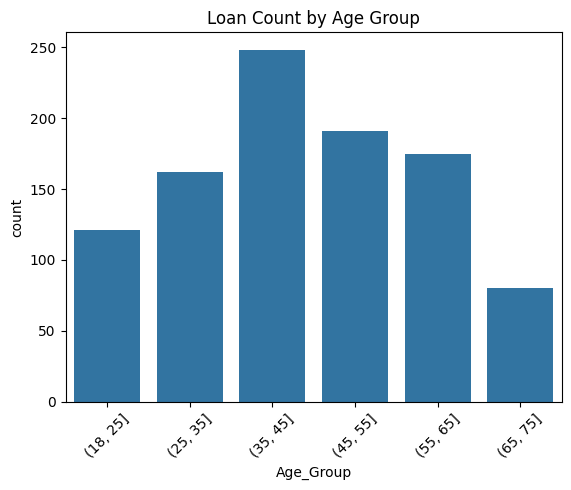

In [ ]:
# Create Age Groups
df['Age_Group'] = pd.cut(df['age'], bins=[18,25,35,45,55,65,75])

plt.figure()
sns.countplot(x=df['Age_Group'])
plt.title("Loan Count by Age Group")
plt.xticks(rotation=45)
plt.show()

Most loans are taken by individuals in the 35–45 age group, followed by the 45–55 age group, while the 65–75 group takes the least loans.

In [ ]:
df.to_csv("final_customer_cleaned.csv", index=False)